# 01 · Understanding the transactions

**Learning question:** how common is fraud in this dataset, and how does the answer change by transaction type?

This is an undergraduate statistics and Python exercise using PaySim, a **synthetic** mobile-money dataset.
The aim is to practise grouped summaries, conditional proportions and plots before fitting a simple model.
It does not measure the fraud risk of a real bank. Amounts are in dataset currency units, not GBP.

Follow the [data instructions](data/README.md), select the project Python environment and run from the project root.
The full learning sequence is 01 → 02 → 03. The script in `scripts/` is an optional way to run all three.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

DATA = Path('data/PS_20174392719_1491204439457_log.csv')
TABLES = Path('reports/tables')
FIGURES = Path('reports/figures')
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': 0.2})

# Read just the columns needed for this exercise to reduce memory use.
columns = ['step', 'type', 'amount', 'oldbalanceOrg', 'isFraud']
data = pd.read_csv(DATA, usecols=columns, dtype={'type': 'category'})
display(data.head())
print(f'{len(data):,} transactions; simulation steps {data.step.min()}–{data.step.max()}')

Matplotlib is building the font cache; this may take a moment.


,step,type,amount,oldbalanceOrg,isFraud
0,1,PAYMENT,9839.64,170136.0,0
1,1,PAYMENT,1864.28,21249.0,0
2,1,TRANSFER,181.00,181.0,1
3,1,CASH_OUT,181.00,181.0,1
4,1,PAYMENT,11668.14,41554.0,0


6,362,620 transactions; simulation steps 1–743


## 1. Check the data before calculating rates

`isFraud` is 1 for labelled fraud and 0 otherwise, so its mean is the fraction labelled fraud.
We check missing values in the **five loaded columns**, binary labels and non-negative amounts.
Zero amounts are counted rather than removed. These checks are not a full audit of account IDs or duplicates.

In [2]:
quality = data.isna().sum().rename('missing_values').to_frame()
display(quality)
assert quality['missing_values'].sum() == 0
assert data['isFraud'].isin([0, 1]).all()
assert np.isfinite(data[['amount', 'oldbalanceOrg', 'step']]).all().all()
assert data['amount'].ge(0).all() and data['oldbalanceOrg'].ge(0).all()
assert data['step'].between(1, 743).all()
assert data['step'].eq(np.floor(data['step'])).all()
print(f'Zero-amount transactions: {data.amount.eq(0).sum():,}')
quality.to_csv(TABLES / 'data_quality.csv', index_label='column')

,missing_values
step,0
type,0
amount,0
oldbalanceOrg,0
isFraud,0


Zero-amount transactions: 16


## 2. Overall probability versus probability within a type

Each type's fraud rate is `fraud in that type / all transactions of that type`.
This is an empirical estimate of **P(fraud | transaction type)**, not the share of all fraud belonging to that type.
For modelling, we focus on TRANSFER and CASH_OUT because the fraud labels in this file occur only there.
That observation does not imply that other payment types are always safe in real life.

,population,transactions,fraud,fraud_percent
0,All transactions,6362620,8213,0.1291
1,TRANSFER / CASH_OUT,2770409,8213,0.2965


,transactions,fraud,fraud_rate,fraud_percent
type,,,,
CASH_IN,1399284,0,0.0000,0.0000
CASH_OUT,2237500,4116,0.0018,0.1840
DEBIT,41432,0,0.0000,0.0000
PAYMENT,2151495,0,0.0000,0.0000
TRANSFER,532909,4097,0.0077,0.7688


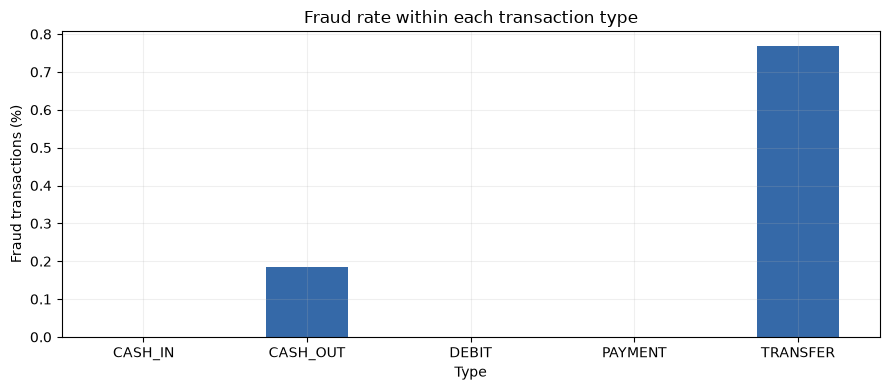

In [3]:
by_type = data.groupby('type', observed=True)['isFraud'].agg(
    transactions='size', fraud='sum', fraud_rate='mean')
by_type['fraud_percent'] = 100 * by_type['fraud_rate']
eligible = data.loc[data['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
population = pd.DataFrame([
    {'population': name, 'transactions': len(frame), 'fraud': int(frame.isFraud.sum()),
     'fraud_percent': 100 * frame.isFraud.mean()}
    for name, frame in [('All transactions', data), ('TRANSFER / CASH_OUT', eligible)]
])
display(population.round(4))
display(by_type.round(4))
population.to_csv(TABLES / 'population.csv', index=False)
by_type.to_csv(TABLES / 'fraud_by_type.csv', index_label='type')

fig, ax = plt.subplots()
by_type['fraud_percent'].plot.bar(ax=ax, color='#3569a8', rot=0)
ax.set(title='Fraud rate within each transaction type', ylabel='Fraud transactions (%)', xlabel='Type')
fig.tight_layout()
fig.savefig(FIGURES / 'fraud_by_type.png', dpi=150)
plt.show()

## 3. Amounts: frequency and size are different questions

A fraud rate measures frequency. Transaction amount describes size, but is **not necessarily the final loss**.
We compare medians and upper quartiles because a few large transactions can dominate an average.
The histogram uses `log10(1 + amount)` to make the long right tail readable and allow zero amounts.
Each class has its own density scale: the curves compare shapes, not the relative number of fraud records.

,transactions,mean_amount,median_amount,upper_quartile
isFraud,,,,
0,2762196,314115.5,171034.46,305994.18
1,8213,1467967.3,441423.44,1517771.48


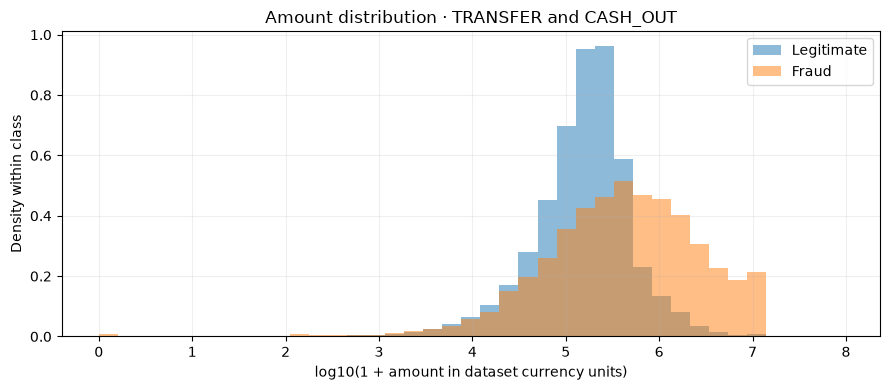

In [4]:
amounts = eligible.groupby('isFraud')['amount'].agg(
    transactions='size', mean_amount='mean', median_amount='median',
    upper_quartile=lambda values: values.quantile(0.75))
display(amounts.round(2))
amounts.to_csv(TABLES / 'amount_by_label.csv', index_label='isFraud')
fig, ax = plt.subplots()
bins = np.linspace(0, np.log10(1 + eligible.amount.max()), 40)
for label, name in [(0, 'Legitimate'), (1, 'Fraud')]:
    values = eligible.loc[eligible.isFraud.eq(label), 'amount']
    ax.hist(np.log10(1 + values), bins=bins, density=True, alpha=0.5, label=name)
ax.set(title='Amount distribution · TRANSFER and CASH_OUT',
       xlabel='log10(1 + amount in dataset currency units)', ylabel='Density within class')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'amount_distribution.png', dpi=150)
plt.show()

## 4. Time and changing denominators

One `step` is a simulation hour, not a dated real-world observation. The table retains the original time boundaries.
The final period has **already been inspected** in an earlier version. This description does not create a new test set.
Compare fraud and legitimate transactions per elapsed step before interpreting a change in the fraud percentage.

In [5]:
rows = []
for name, start, end in [('Training', 1, 323), ('Validation', 324, 377),
                         ('Previously inspected later period', 378, 743)]:
    part = eligible.loc[eligible.step.between(start, end)]
    fraud = int(part.isFraud.sum())
    rows.append({'period': name, 'first_step': start, 'last_step': end,
                 'transactions': len(part), 'fraud': fraud,
                 'fraud_percent': 100 * fraud / len(part),
                 'fraud_per_step': fraud / (end - start + 1),
                 'legitimate_per_step': (len(part) - fraud) / (end - start + 1)})
time_summary = pd.DataFrame(rows)
display(time_summary.round(4))
time_summary.to_csv(TABLES / 'time_summary.csv', index=False)
display(Markdown(
    f"Across all {len(data):,} transactions, **{data.isFraud.mean():.4%}** are labelled fraud. "
    f"Within the {len(eligible):,} eligible transactions, the rate is **{eligible.isFraud.mean():.4%}**. "
    "The different denominators explain why these two rates differ."
))

,period,first_step,last_step,transactions,fraud,fraud_percent,fraud_per_step,legitimate_per_step
0,Training,1,323,1951895,3643,0.1866,11.2786,6031.7399
1,Validation,324,377,410437,560,0.1364,10.3704,7590.3148
2,Previously inspected later period,378,743,408077,4010,0.9827,10.9563,1104.0082


Across all 6,362,620 transactions, **0.1291%** are labelled fraud. Within the 2,770,409 eligible transactions, the rate is **0.2965%**. The different denominators explain why these two rates differ.

## Conclusions

- Fraud is rare and confined to TRANSFER and CASH_OUT in this file. A model that always says “legitimate” can have high accuracy while detecting no fraud.
- Amounts are skewed. Describing both frequency and size is more useful than reporting only an overall average.
- The later period has a higher fraud percentage. The table shows similar fraud counts per step and fewer legitimate transactions per step. This is an observation, not proof of a change in actual banking risk. Simulation schedules or extraction choices are possible explanations; this file does not establish the cause.

## Feature timing and limitations

| Field | How it is used |
|---|---|
| Requested amount and type | Inputs for the simple model, available when a transaction is initiated. |
| Opening balance | Descriptive field only. Its name suggests a pre-transaction value, but the publisher warns about the simulation's balance fields. |
| Closing balances and balance-error features | Post-transaction information; excluded from the model. |
| `isFraud` | Retrospective label, never an input. |

The data are synthetic and cover one simulation. Counts are transactions, not unique people or fraud cases.
We do not have confirmation dates, recoveries or net losses. These observations cannot establish real-bank performance.
The next notebook uses amount and type only and explains its development-only evaluation.